# Ablation 04 — Activation-Family Bake-off: TopK vs BatchTopK vs JumpReLU

Does the **activation function family** drive concept reproducibility, or is the
~0.004 baseline cross-seed Jaccard an artifact of TopK's hard per-sample k?

Three SAE families trained on the **same** BiomedCLIP IU X-Ray embeddings at
**matched** configuration, compared on reconstruction, dead-feature rate,
effective-L0, within-family stability, and **cross-family consensus**.

| Variant | Sparsity mechanism | Free sparsity knob |
|---|---|---|
| **TopK** | hard top-k per sample (baseline) | `k=32` |
| **BatchTopK** | global top-(k·B) across the batch → adaptive per-sample L0 | `k=32` |
| **JumpReLU** | learned per-feature threshold + straight-through estimator | `target_l0=32` |

### Pre-registered hypothesis
At matched lr, BatchTopK / JumpReLU yield **higher consensus-rate** and
**lower dead%** than TopK, because both allow features to specialize on the
samples that need them rather than forcing exactly k=32 active per sample.

### Methodological protocol (hard rules — see CLAUDE.md)
1. **Within-group Jaccard only.** Renormalize active sets to `n=20` and compute
   Jaccard within each family. Cross-family comparison uses index/size-agnostic
   metrics (signal-to-null ratio, consensus-reappearance, cross-activation
   consensus). `compute_stability` is NOT used (hardcodes `AutoEncoderTopK`).
2. **Output-dir isolation.** PathsConfig overridden to
   `models/ablation_a4/{topk,batchtopk,jumprelu}_2048/`, `results/ablation/`.
3. **No vocab rebuild** — committed `data/vocabulary.json` + `text_vocab_embeddings.pt` used as-is.
4. **Safe deserialization** — all `torch.load` via `utils.load_tensor` / `utils.load_state_dict`.
5. **Test-set discipline** — stability / Jaccard / naming / dead% on TEST only.
6. **Reproducibility** — threads + hashseed pinned before importing torch;
   ablation seeds `(0, 42, 123)`; primary_seed=42 for naming.

### Fixed parameters
- `dict_size = 2048` (shared index space across all 3 families)
- `lr = 5e-5` **pinned & matched** across all 3 families
- `steps = 12000`, seeds `(0, 42, 123)`
- `k = 32` (TopK, BatchTopK); `target_l0 = 32` (JumpReLU)
- `normalize_activations = False` (matches `SAEManager.train`)
- Naming is **gap-corrected** (`W_dec -= visual_centroid - text_centroid`).

### Baseline reference (dict_size=4096, gap-corrected)
reconstruction cosine 0.988, dead ~44%, cross-seed mean index-Jaccard 0.0038,
naming decoder<->vocab cosine mean 0.3949 / max 0.5457 (seed 42).

## 0. Setup & Configuration

In [1]:
# Reproducibility — pin threads + hashseed BEFORE importing torch.
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'  # best-effort inside a running kernel

import sys
import json
import shutil
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np

# Resolve project root (walk up until 'src/' exists).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch:      {torch.__version__}')
print(f'Device:       {DEVICE}')

Project root: /Users/marcantoniolopez/Documents/github/xai-project-5
PyTorch:      2.12.0
Device:       mps


In [2]:
import config
import utils

# Output-dir isolation (hard rule #2): PathsConfig is mutable, override to per-variant subdirs.
MODELS_ROOT = PROJECT_ROOT / 'models' / 'ablation_a4'   # per-variant leaves below
RESULTS_DIR = PROJECT_ROOT / 'results' / 'ablation'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'ablation'
MODELS_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Re-point config.paths to the isolated roots (do NOT touch baseline models/results).
config.paths.models_dir = MODELS_ROOT
config.paths.results_dir = RESULTS_DIR
config.paths.figures_dir = FIGURES_DIR

# Ablation parameters (frozen locals — never mutate the frozen SAEConfig).
DICT_SIZE = 2048          # shared index space across all 3 families
ACTIVATION_DIM = config.sae.activation_dim   # 512
LR = 5e-5                 # PINNED & MATCHED across all families (kills lr confound)
N_STEPS = 12000
BATCH_SIZE = 256
LOG_STEPS = 1000
WARMUP_STEPS = 1000
K = 32                    # TopK + BatchTopK
TARGET_L0 = 32.0          # JumpReLU
BANDWIDTH = 0.001
SPARSITY_PENALTY = 1.0
SPARSITY_WARMUP_STEPS = 2000
AUXK_ALPHA = 1.0 / 32.0
ABLATION_SEEDS = (0, 42, 123)
PRIMARY_SEED = 42

# Per-variant save roots (each variant gets its own subdir -> sae_seed{N} leaves).
VARIANT_DIRS = {
    'topk':      MODELS_ROOT / 'topk_2048',
    'batchtopk': MODELS_ROOT / 'batchtopk_2048',
    'jumprelu':  MODELS_ROOT / 'jumprelu_2048',
}
for d in VARIANT_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print('=== Activation Bake-off Configuration ===')
print(f'  dict_size:        {DICT_SIZE}')
print(f'  activation_dim:   {ACTIVATION_DIM}')
print(f'  lr (matched):     {LR}')
print(f'  steps:            {N_STEPS}')
print(f'  seeds:            {ABLATION_SEEDS}  (primary={PRIMARY_SEED})')
print(f'  k / target_l0:    {K} / {TARGET_L0}')
print(f'  auxk_alpha:       {AUXK_ALPHA}')
print(f'  jumprelu kwargs:  bandwidth={BANDWIDTH}, sparsity_penalty={SPARSITY_PENALTY}, sparsity_warmup={SPARSITY_WARMUP_STEPS}')
print(f'  normalize_activations: False')
print(f'  models root:      {MODELS_ROOT}')
print(f'  results dir:      {RESULTS_DIR}')
print(f'  figures dir:      {FIGURES_DIR}')

/Users/marcantoniolopez/Documents/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Activation Bake-off Configuration ===
  dict_size:        2048
  activation_dim:   512
  lr (matched):     5e-05
  steps:            12000
  seeds:            (0, 42, 123)  (primary=42)
  k / target_l0:    32 / 32.0
  auxk_alpha:       0.03125
  jumprelu kwargs:  bandwidth=0.001, sparsity_penalty=1.0, sparsity_warmup=2000
  normalize_activations: False
  models root:      /Users/marcantoniolopez/Documents/github/xai-project-5/models/ablation_a4
  results dir:      /Users/marcantoniolopez/Documents/github/xai-project-5/results/ablation
  figures dir:      /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation


In [3]:
# Verify the shared inputs exist (no vocab rebuild — hard rule #3).
inputs = {
    'train_embeddings': config.paths.train_embeddings_path,
    'test_embeddings':  config.paths.test_embeddings_path,
    'vocab_embeddings': config.paths.vocab_embeddings_path,
    'vocab_labels':     config.paths.vocab_labels_path,
}
print('=== Input verification ===')
all_ok = True
for name, p in inputs.items():
    ok = p.exists()
    print(f'  [{"OK" if ok else "MISSING"}] {name:18s} -> {p}')
    all_ok &= ok
assert all_ok, 'Missing inputs — run the baseline pipeline / extract embeddings first.'

train_emb = utils.load_tensor(config.paths.train_embeddings_path)   # (5976, 512)
test_emb  = utils.load_tensor(config.paths.test_embeddings_path)    # (1494, 512)
vocab_emb = utils.load_tensor(config.paths.vocab_embeddings_path)
with open(config.paths.vocab_labels_path) as f:
    # vocabulary.json entries may be dicts or strings; normalize to term strings.
    vocab_labels = [
        e['term'] if isinstance(e, dict) else e for e in json.load(f)
    ]

print(f'\ntrain_emb: {tuple(train_emb.shape)}  test_emb: {tuple(test_emb.shape)}')
print(f'vocab_emb: {tuple(vocab_emb.shape)}  vocab_labels: {len(vocab_labels)} terms')
print(f'  train |x|_2 mean: {train_emb.norm(dim=1).mean():.4f}  (expect ~1.0, L2-normalized)')

=== Input verification ===
  [OK] train_embeddings   -> /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/standard/train_embeddings.pt
  [OK] test_embeddings    -> /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/standard/test_embeddings.pt
  [OK] vocab_embeddings   -> /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/standard/text_vocab_embeddings.pt
  [OK] vocab_labels       -> /Users/marcantoniolopez/Documents/github/xai-project-5/data/vocabulary.json

train_emb: (5976, 512)  test_emb: (1494, 512)
vocab_emb: (508, 512)  vocab_labels: 508 terms
  train |x|_2 mean: 1.0000  (expect ~1.0, L2-normalized)


## 0.1 Variant-aware library imports

We wire the three trainer/model classes through `trainSAE` directly (NOT
`SAEManager.train`, which hardcodes `TopKTrainer` and omits `auxk_alpha`).

Key library gotchas (confirmed via `inspect.signature`):
- `JumpReluTrainer` has **no `k`**, **no auto-lr**, and **`device` defaults to 'cpu'** — must pass explicitly.
- Each `trainSAE` trainer config dict must carry a `'trainer'` key (the class object).
- Final weights land at `save_dir/trainer_0/ae.pt`.

In [4]:
from dictionary_learning.trainers.top_k import AutoEncoderTopK, TopKTrainer
from dictionary_learning.trainers.batch_top_k import BatchTopKSAE, BatchTopKTrainer
from dictionary_learning.trainers.jumprelu import JumpReluTrainer
from dictionary_learning.dictionary import JumpReluAutoEncoder
from dictionary_learning.training import trainSAE

print('Trainers :', TopKTrainer.__name__, BatchTopKTrainer.__name__, JumpReluTrainer.__name__)
print('Models   :', AutoEncoderTopK.__name__, BatchTopKSAE.__name__, JumpReluAutoEncoder.__name__)
print('trainSAE :', trainSAE.__module__)

# Shared training data generator (seeded per-call for determinism).
def batch_generator(emb, batch_size, seed):
    gen = torch.Generator().manual_seed(seed)
    while True:
        perm = torch.randperm(len(emb), generator=gen)
        for i in range(0, len(perm), batch_size):
            yield emb[perm[i:i + batch_size]].to(DEVICE)

Trainers : TopKTrainer BatchTopKTrainer JumpReluTrainer
Models   : AutoEncoderTopK BatchTopKSAE JumpReluAutoEncoder
trainSAE : dictionary_learning.training


## 1. Training — three families, matched config

Each variant trains 3 seeds (`0, 42, 123`) routed through `trainSAE` with an
explicit, family-specific `trainer_cfg`. The `decay_start` is set to
`int(N_STEPS * 0.8)` to mirror `SAEManager.train`. `normalize_activations=False`
matches `SAEManager.train` (the embeddings are already L2-normalized).

**~10 min/family on GPU; hours on CPU. Do NOT run this cell unless you intend to train.**

In [5]:
DECAY_START = int(N_STEPS * 0.8)
AUTOCAST_DTYPE = torch.float32 if DEVICE in ('cpu', 'mps') else torch.bfloat16

def make_trainer_cfg(variant, seed):
    """Build the family-specific trainer_config dict for trainSAE."""
    common = {
        'activation_dim': ACTIVATION_DIM,
        'dict_size': DICT_SIZE,
        'steps': N_STEPS,
        'layer': 0,
        'lm_name': 'biomedclip',
        'lr': LR,                      # PINNED & matched
        'warmup_steps': WARMUP_STEPS,
        'decay_start': DECAY_START,
        'seed': seed,
        'device': DEVICE,
    }
    if variant == 'topk':
        cfg = {'trainer': TopKTrainer, **common, 'k': K, 'auxk_alpha': AUXK_ALPHA}
    elif variant == 'batchtopk':
        cfg = {'trainer': BatchTopKTrainer, **common, 'k': K, 'auxk_alpha': AUXK_ALPHA}
    elif variant == 'jumprelu':
        # JumpReLU: NO k; sparsity driven by target_l0. device MUST be explicit (default 'cpu').
        cfg = {
            'trainer': JumpReluTrainer, **common,
            'target_l0': TARGET_L0,
            'bandwidth': BANDWIDTH,
            'sparsity_penalty': SPARSITY_PENALTY,
            'sparsity_warmup_steps': SPARSITY_WARMUP_STEPS,
        }
    else:
        raise ValueError(variant)
    return cfg

def train_variant(variant, seeds):
    """Train all seeds for one family into its isolated subdir."""
    variant_root = VARIANT_DIRS[variant]
    for seed in seeds:
        seed_dir = variant_root / f'sae_seed{seed}'
        ae_path = seed_dir / 'trainer_0' / 'ae.pt'
        if ae_path.exists():
            print(f'  [{variant}] seed={seed} already trained -> {ae_path}')
            continue
        if seed_dir.exists():
            shutil.rmtree(seed_dir)
        print(f'  [{variant}] training seed={seed} ({N_STEPS} steps, lr={LR}, dict={DICT_SIZE}) ...')
        trainSAE(
            data=batch_generator(train_emb, BATCH_SIZE, seed=seed),
            trainer_configs=[make_trainer_cfg(variant, seed)],
            steps=N_STEPS,
            save_dir=str(seed_dir),
            save_steps=None,
            log_steps=LOG_STEPS,
            device=DEVICE,
            normalize_activations=False,   # match SAEManager.train
            verbose=True,
            autocast_dtype=AUTOCAST_DTYPE,
        )
        print(f'    done -> {ae_path}')

for v in ('topk', 'batchtopk', 'jumprelu'):
    train_variant(v, ABLATION_SEEDS)
print('\nAll variants trained.')

  [topk] training seed=0 (12000 steps, lr=5e-05, dict=2048) ...


  0%|          | 0/12000 [00:00<?, ?it/s]

Step 0: L0 = 32.0, frac_variance_explained = -0.3665425777435303


  0%|          | 1/12000 [00:00<32:29,  6.15it/s]

  0%|          | 7/12000 [00:00<06:30, 30.68it/s]

...

100%|█████████▉| 11979/12000 [02:49<00:00, 71.20it/s]

100%|█████████▉| 11987/12000 [02:49<00:00, 71.13it/s]

100%|█████████▉| 11995/12000 [02:49<00:00, 70.97it/s]

100%|██████████| 12000/12000 [02:49<00:00, 70.74it/s]

    done -> /Users/marcantoniolopez/Documents/github/xai-project-5/models/ablation_a4/jumprelu_2048/sae_seed123/trainer_0/ae.pt

All variants trained.


## 2. Bespoke loaders (family-specific)

`SAEManager.load` instantiates `AutoEncoderTopK` unconditionally and crashes on
BatchTopK/JumpReLU, so each family is loaded directly with `utils.load_state_dict`
(weights_only=True).

Decoder-row extraction differs by family:
- TopK / BatchTopK: `model.decoder.weight` is `(act_dim, dict_size)` → use `.T.clone()`.
- JumpReLU: `model.W_dec` is already `(dict_size, act_dim)` → no transpose.

In [6]:
def _ae_path(model_dir):
    """Locate ae.pt with the trainer_0 fallback that SAEManager.load uses."""
    p1 = model_dir / 'ae.pt'
    p2 = model_dir / 'trainer_0' / 'ae.pt'
    if p1.exists():
        return p1
    if p2.exists():
        return p2
    raise FileNotFoundError(f'No ae.pt under {model_dir}')

def load_model(variant, seed):
    """Load a trained model for a (variant, seed) pair. weights_only=True everywhere."""
    model_dir = VARIANT_DIRS[variant] / f'sae_seed{seed}'
    ae_path = _ae_path(model_dir)
    state = utils.load_state_dict(ae_path, device=DEVICE)   # weights_only=True
    if variant == 'topk':
        m = AutoEncoderTopK(ACTIVATION_DIM, DICT_SIZE, K)
    elif variant == 'batchtopk':
        m = BatchTopKSAE(ACTIVATION_DIM, DICT_SIZE, K)
    elif variant == 'jumprelu':
        m = JumpReluAutoEncoder(ACTIVATION_DIM, DICT_SIZE, device=DEVICE)
    else:
        raise ValueError(variant)
    m.load_state_dict(state)
    m.float().eval().to(DEVICE)
    return m

def get_decoder_rows(variant, model):
    """Return (dict_size, act_dim) decoder rows (one concept direction per row)."""
    if variant in ('topk', 'batchtopk'):
        # decoder.weight is (act_dim, dict_size) -> transpose.
        return model.decoder.weight.data.T.clone().cpu()
    elif variant == 'jumprelu':
        # W_dec is already (dict_size, act_dim).
        return model.W_dec.data.clone().cpu()
    raise ValueError(variant)

# Smoke-test one model per family.
smoke = {}
with torch.no_grad():
    for v in ('topk', 'batchtopk', 'jumprelu'):
        m = load_model(v, PRIMARY_SEED)
        x = test_emb[:64].to(DEVICE)
        x_hat = m(x)
        assert x_hat.shape == x.shape, (v, x_hat.shape)
        W = get_decoder_rows(v, m)
        assert W.shape == (DICT_SIZE, ACTIVATION_DIM), (v, W.shape)
        smoke[v] = F.cosine_similarity(x_hat, x, dim=-1).mean().item()
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
print('Smoke-test reconstruction cosine (seed 42, first 64 test samples):')
for v, c in smoke.items():
    print(f'  {v:10s}: {c:.4f}')

Smoke-test reconstruction cosine (seed 42, first 64 test samples):
  topk      : 0.9923
  batchtopk : 0.9925
  jumprelu  : 0.9916


## 3. Per-variant metrics: reconstruction, dead%, effective L0

**Dead%** is the activation-based definition (fraction of features never nonzero
across the test set), computed standalone. We never read the trainers' internal
`dead_features` counter (its `10_000_000` threshold makes JumpReLU falsely report 0%).

Effective L0 differs by family: TopK = exactly `k=32`; BatchTopK = threshold-gated
at inference; JumpReLU = count of nonzero activations above the learned threshold.

In [7]:
CHUNK = 512

def encode_sparse(variant, model, x):
    """Return the sparse [N, dict_size] activation tensor for each family."""
    outs = []
    with torch.no_grad():
        for i in range(0, len(x), CHUNK):
            xb = x[i:i + CHUNK].to(DEVICE)
            if variant == 'topk':
                outs.append(model.encode(xb, use_threshold=False).cpu())
            elif variant == 'batchtopk':
                # Inference: apply learned threshold (not the training-time global batch-top-k).
                outs.append(model.encode(xb, use_threshold=True).cpu())
            elif variant == 'jumprelu':
                outs.append(model.encode(xb).cpu())
    return torch.cat(outs, dim=0)

def reconstruct(variant, model, x):
    """x_hat via full forward (encode+decode). Mirrors SAEManager.compute_cosine_reconstruction."""
    hats = []
    with torch.no_grad():
        for i in range(0, len(x), CHUNK):
            xb = x[i:i + CHUNK].to(DEVICE)
            hats.append(model(xb).cpu())
    return torch.cat(hats, dim=0)

def recon_cos(x_hat, x):
    return F.cosine_similarity(x_hat, x, dim=-1).mean().item()

per_variant_metrics = {}
for v in ('topk', 'batchtopk', 'jumprelu'):
    seeds_metrics = {}
    for seed in ABLATION_SEEDS:
        m = load_model(v, seed)
        sparse = encode_sparse(v, m, test_emb)          # (N, dict_size)
        x_hat = reconstruct(v, m, test_emb)

        active_per_feature = (sparse != 0).float().sum(dim=0)   # (dict_size,)
        n_dead = int((active_per_feature == 0).sum().item())
        dead_pct = 100.0 * n_dead / sparse.shape[1]
        l0_per_sample = (sparse != 0).float().sum(dim=1)        # (N,)
        # activation entropy (frequency-based, matches compute_sparsity_metrics)
        freq = active_per_feature / (active_per_feature.sum() + 1e-8)
        freq_nz = freq[freq > 0]
        entropy = (-(freq_nz * freq_nz.log())).sum().item() if freq_nz.numel() else 0.0

        seeds_metrics[seed] = {
            'recon_cos':   recon_cos(x_hat, test_emb),
            'mse':         ((x_hat - test_emb) ** 2).mean().item(),
            'l0_mean':     float(l0_per_sample.mean().item()),
            'l0_std':      float(l0_per_sample.std().item()),
            'dead_pct':    dead_pct,
            'utilization_pct': 100.0 - dead_pct,
            'entropy':     entropy,
            'l0_per_sample': l0_per_sample.numpy(),   # for the histogram
        }
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    per_variant_metrics[v] = seeds_metrics

# Aggregate across seeds (mean +/- std).
print(f"{'variant':10s} {'seed':>5s} {'recon_cos':>9s} {'mse':>10s} {'L0':>7s} {'dead%':>7s} {'util%':>7s}")
for v in ('topk', 'batchtopk', 'jumprelu'):
    for seed in ABLATION_SEEDS:
        s = per_variant_metrics[v][seed]
        print(f"{v:10s} {seed:>5d} {s['recon_cos']:>9.4f} {s['mse']:>10.2e} "
              f"{s['l0_mean']:>7.2f} {s['dead_pct']:>7.1f} {s['utilization_pct']:>7.1f}")
    agg_recon = np.mean([per_variant_metrics[v][s]['recon_cos'] for s in ABLATION_SEEDS])
    agg_dead = np.mean([per_variant_metrics[v][s]['dead_pct'] for s in ABLATION_SEEDS])
    print(f"{v:10s} {'mean':>5s} {agg_recon:>9.4f} {'':>10s} {'':>7s} {agg_dead:>7.1f}")
    print()

variant     seed recon_cos        mse      L0   dead%   util%
topk           0    0.9912   3.43e-05   32.00    16.2    83.8
topk          42    0.9914   3.37e-05   32.00    16.4    83.6
topk         123    0.9914   3.36e-05   32.00    16.4    83.6
topk        mean    0.9913                       16.3

batchtopk      0    0.9915   3.41e-05   38.59     4.3    95.7
batchtopk     42    0.9916   3.32e-05   38.53     5.2    94.8
batchtopk    123    0.9917   3.30e-05   38.64     4.6    95.4
batchtopk   mean    0.9916                        4.7

jumprelu       0    0.9908   3.84e-05   33.79    48.5    51.5
jumprelu      42    0.9906   3.88e-05   33.78    46.4    53.6
jumprelu     123    0.9906   3.92e-05   33.84    48.2    51.8
jumprelu    mean    0.9907                       47.7



## 4. Effective-L0 distribution per family (novelty: adaptive sparsity)

TopK pins L0=32 exactly. BatchTopK (threshold-gated at inference) and JumpReLU
(learned threshold) produce a **distribution** of per-sample active counts —
this is the adaptive-sparsity behaviour that is unstudied on medical VLMs.

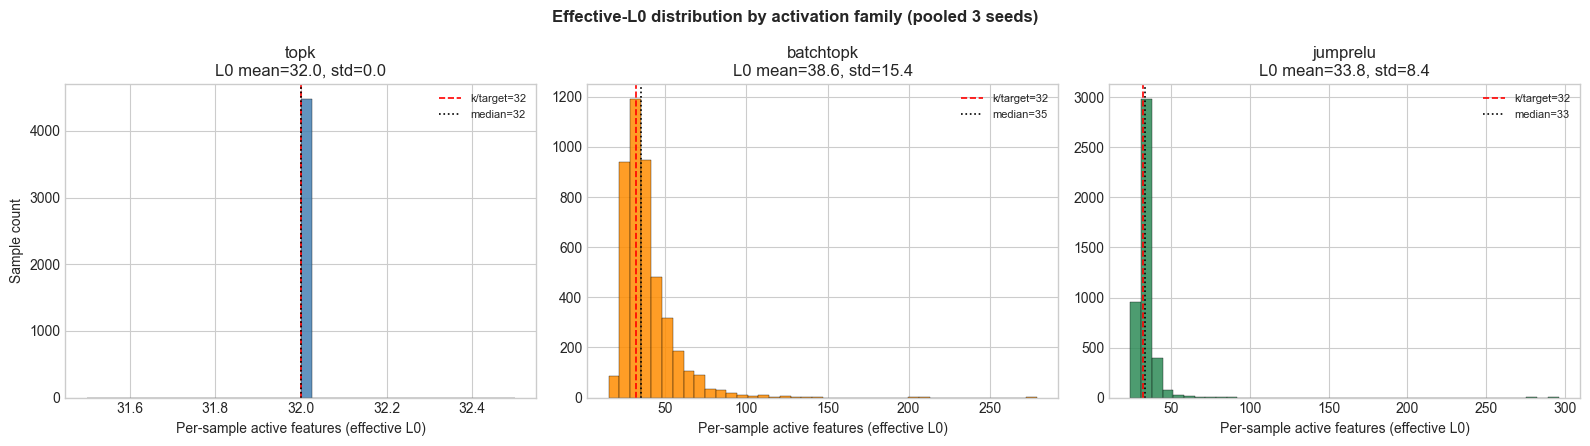

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation/a4_effective_l0_distribution.png


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
colors = {'topk': 'steelblue', 'batchtopk': 'darkorange', 'jumprelu': 'seagreen'}
for ax, v in zip(axes, ('topk', 'batchtopk', 'jumprelu')):
    all_l0 = np.concatenate([per_variant_metrics[v][s]['l0_per_sample'] for s in ABLATION_SEEDS])
    ax.hist(all_l0, bins=40, color=colors[v], alpha=0.85, edgecolor='black', linewidth=0.3)
    ax.axvline(K, color='red', linestyle='--', linewidth=1.2, label=f'k/target={K}')
    ax.axvline(np.median(all_l0), color='black', linestyle=':', linewidth=1.2,
               label=f'median={np.median(all_l0):.0f}')
    ax.set_title(f'{v}\nL0 mean={all_l0.mean():.1f}, std={all_l0.std():.1f}')
    ax.set_xlabel('Per-sample active features (effective L0)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Sample count')
fig.suptitle('Effective-L0 distribution by activation family (pooled 3 seeds)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_effective_l0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_effective_l0_distribution.png"}')

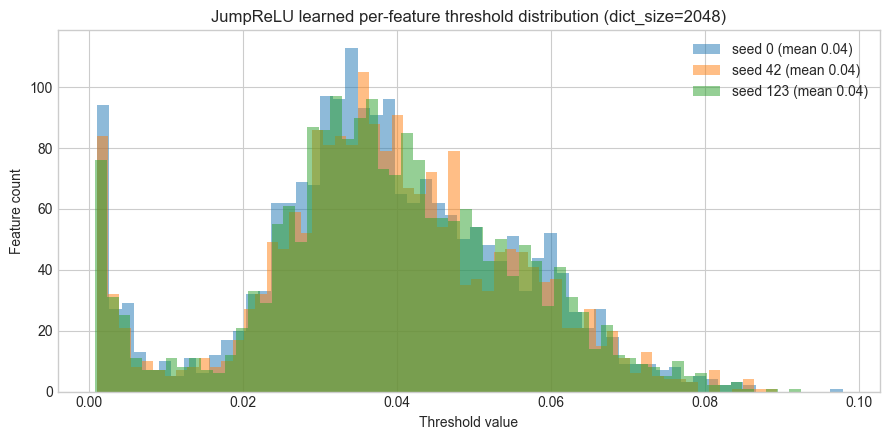

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation/a4_jumprelu_threshold_hist.png


In [9]:
# JumpReLU learned-threshold distribution (the per-feature gate that drives adaptive sparsity).
fig, ax = plt.subplots(figsize=(9, 4.5))
for seed in ABLATION_SEEDS:
    m = load_model('jumprelu', seed)
    thr = m.threshold.detach().cpu().numpy()
    ax.hist(thr, bins=60, alpha=0.5, label=f'seed {seed} (mean {thr.mean():.2f})')
    del m
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
ax.set_title('JumpReLU learned per-feature threshold distribution (dict_size=2048)')
ax.set_xlabel('Threshold value')
ax.set_ylabel('Feature count')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_jumprelu_threshold_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_jumprelu_threshold_hist.png"}')

## 5. Within-family stability (renormalized active-set Jaccard)

We cannot use `SAEManager.compute_stability` (hardcodes `AutoEncoderTopK`), nor
compare raw active-INDEX sets across families (different effective L0). Hard rule #1:
**Jaccard within-group only, at a common active-set size.**

Protocol (per family, over its 3 seeds):
1. Build per-sample top-n active-INDEX sets with `n=N_ACTIVE=20` so the Jaccard
   denominator is comparable across families.
2. Average Jaccard over samples, then strict-upper-triangle mean/std across the
   3 seed pairs — the same statistic `compute_stability` returns.

The **signal-to-null ratio** = `mean_jaccard / (N_ACTIVE / dict_size)` measures
how much observed overlap exceeds the random-overlap floor (20 of 2048).

In [10]:
N_ACTIVE = 20   # common active-set size for fair cross-family Jaccard (hard rule #1)

def topn_active_indices(variant, model, x, n):
    """Per-sample set of the n highest-|activation| feature indices, as a list[set[int]]."""
    sets = []
    with torch.no_grad():
        for i in range(0, len(x), CHUNK):
            xb = x[i:i + CHUNK].to(DEVICE)
            if variant == 'topk':
                sparse = model.encode(xb, use_threshold=False)
            elif variant == 'batchtopk':
                sparse = model.encode(xb, use_threshold=True)
            elif variant == 'jumprelu':
                sparse = model.encode(xb)
            # top-n by magnitude (clamp to feature count; keep only nonzero).
            vals, idx = sparse.abs().topk(min(n, sparse.shape[1]), dim=1, sorted=False)
            for r in range(idx.shape[0]):
                row_idx = idx[r].tolist()
                row_vals = vals[r]
                keep = [row_idx[j] for j in range(len(row_idx)) if row_vals[j].item() > 0]
                sets.append(set(keep))
    return sets

def stability_from_active_sets(active_sets, n_seeds, n_samples):
    """Standalone Jaccard loop (mirrors SAEManager.compute_stability math)."""
    jm = torch.zeros(n_seeds, n_seeds)
    for i in range(n_seeds):
        for j in range(i, n_seeds):
            if i == j:
                jm[i, j] = 1.0
                continue
            jac = []
            for s in range(n_samples):
                a, b = active_sets[i][s], active_sets[j][s]
                union = len(a | b)
                jac.append(len(a & b) / union if union > 0 else 0.0)
            mean_j = sum(jac) / len(jac)
            jm[i, j] = mean_j
            jm[j, i] = mean_j
    mask = torch.triu(torch.ones(n_seeds, n_seeds), diagonal=1).bool()
    upper = jm[mask]
    return {
        'jaccard_matrix': jm,
        'mean_jaccard': upper.mean().item() if upper.numel() else 0.0,
        'std_jaccard': upper.std(correction=0).item() if upper.numel() > 1 else 0.0,
    }

within_stability = {}
n_samples = test_emb.shape[0]
for v in ('topk', 'batchtopk', 'jumprelu'):
    per_seed_sets = []
    for seed in ABLATION_SEEDS:
        m = load_model(v, seed)
        per_seed_sets.append(topn_active_indices(v, m, test_emb, N_ACTIVE))
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    res = stability_from_active_sets(per_seed_sets, len(ABLATION_SEEDS), n_samples)
    random_floor = N_ACTIVE / DICT_SIZE
    res['signal_to_null'] = res['mean_jaccard'] / random_floor if random_floor > 0 else float('inf')
    res['random_floor'] = random_floor
    within_stability[v] = res
    print(f"{v:10s}: mean Jaccard (n={N_ACTIVE}, {len(ABLATION_SEEDS)} seeds) = "
          f"{res['mean_jaccard']:.5f}  (std {res['std_jaccard']:.5f}, "
          f"signal/null = {res['signal_to_null']:.2f}x over floor {random_floor:.5f})")

topk      : mean Jaccard (n=20, 3 seeds) = 0.00463  (std 0.00095, signal/null = 0.47x over floor 0.00977)


batchtopk : mean Jaccard (n=20, 3 seeds) = 0.00357  (std 0.00082, signal/null = 0.37x over floor 0.00977)


jumprelu  : mean Jaccard (n=20, 3 seeds) = 0.00008  (std 0.00006, signal/null = 0.01x over floor 0.00977)


## 6. Consensus reappearance rate (index-agnostic, per family)

Following the a0 approach: pool the 3 seeds' **live decoder rows** for one
family, cosine-cluster at `tau=0.90`, and count clusters that span `>=2/3`
seeds. This is a robustness metric that does NOT depend on the shared index
space (two seeds never agree on feature indices, but they may rediscover the
same concept *direction*).

In [11]:
def consensus_reappearance(variant, tau=0.90, min_seeds=2):
    """Pool live decoder rows across a family's seeds, cluster by cosine, count
    clusters spanning >= min_seeds seeds. Returns summary dict."""
    rows, seed_tags = [], []
    dead_threshold = 1e-8
    for si, seed in enumerate(ABLATION_SEEDS):
        m = load_model(variant, seed)
        W = get_decoder_rows(variant, m)                 # (dict_size, act_dim)
        norms = W.norm(dim=1)
        live = (norms >= dead_threshold).nonzero(as_tuple=True)[0]
        rows.append(F.normalize(W[live], dim=1))
        seed_tags.append(torch.full((len(live),), si, dtype=torch.long))
        del m
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    R = torch.cat(rows, dim=0)                           # (M, act_dim)
    tags = torch.cat(seed_tags, dim=0)                  # (M,)
    M = R.shape[0]

    # Greedy cosine clustering at tau (chunked to bound memory).
    assigned = torch.full((M,), -1, dtype=torch.long)
    cluster_id = 0
    cluster_seed_sets = []
    for i in range(M):
        if assigned[i] >= 0:
            continue
        sims = []
        for j0 in range(0, M, 2048):
            sims.append(R[i:i+1] @ R[j0:j0+2048].T)
        sim = torch.cat(sims, dim=1).squeeze(0)         # (M,)
        members = (sim >= tau).nonzero(as_tuple=True)[0]
        assigned[members] = cluster_id
        cluster_seed_sets.append(set(tags[m].item() for m in members))
        cluster_id += 1

    n_clusters = cluster_id
    n_consensus = sum(1 for s in cluster_seed_sets if len(s) >= min_seeds)
    n_all3 = sum(1 for s in cluster_seed_sets if len(s) >= 3)
    return {
        'n_pooled_rows': int(M),
        'n_clusters': n_clusters,
        'n_consensus': n_consensus,
        'consensus_rate': n_consensus / n_clusters if n_clusters else 0.0,
        'n_spanning_all3': n_all3,
        'spanning_all3_rate': n_all3 / n_clusters if n_clusters else 0.0,
    }

consensus = {v: consensus_reappearance(v, tau=0.90, min_seeds=2) for v in ('topk', 'batchtopk', 'jumprelu')}
print(f"{'variant':10s} {'pooled':>7s} {'clusters':>8s} {'consensus':>9s} {'rate':>7s} {'all3':>5s} {'all3%':>6s}")
for v in ('topk', 'batchtopk', 'jumprelu'):
    c = consensus[v]
    print(f"{v:10s} {c['n_pooled_rows']:>7d} {c['n_clusters']:>8d} {c['n_consensus']:>9d} "
          f"{c['consensus_rate']:>7.3f} {c['n_spanning_all3']:>5d} {c['spanning_all3_rate']*100:>5.1f}%")

variant     pooled clusters consensus    rate  all3  all3%
topk          6144     6144         0   0.000     0   0.0%
batchtopk     6144     6144         0   0.000     0   0.0%
jumprelu      6144     6144         0   0.000     0   0.0%


## 7. Cross-activation consensus (family-invariant concepts)

The headline novelty claim: which concept directions are **family-invariant**?
Pool all **9 models** (3 families x 3 seeds) live decoder rows, cosine-cluster
at `tau=0.90`, count clusters spanning `>=2` **activation families**. A high
rate means the same concepts are rediscovered regardless of the sparsity
mechanism — a strong robustness statement.

In [12]:
def cross_activation_consensus(tau=0.90, min_families=2):
    family_idx = {'topk': 0, 'batchtopk': 1, 'jumprelu': 2}
    rows, fam_tags = [], []
    dead_threshold = 1e-8
    for v in ('topk', 'batchtopk', 'jumprelu'):
        fi = family_idx[v]
        for seed in ABLATION_SEEDS:
            m = load_model(v, seed)
            W = get_decoder_rows(v, m)
            live = (W.norm(dim=1) >= dead_threshold).nonzero(as_tuple=True)[0]
            rows.append(F.normalize(W[live], dim=1))
            fam_tags.append(torch.full((len(live),), fi, dtype=torch.long))
            del m
            if DEVICE == 'cuda':
                torch.cuda.empty_cache()
    R = torch.cat(rows, dim=0)
    tags = torch.cat(fam_tags, dim=0)
    M = R.shape[0]

    assigned = torch.full((M,), -1, dtype=torch.long)
    cluster_id = 0
    cluster_fam_sets = []
    for i in range(M):
        if assigned[i] >= 0:
            continue
        sims = []
        for j0 in range(0, M, 2048):
            sims.append(R[i:i+1] @ R[j0:j0+2048].T)
        sim = torch.cat(sims, dim=1).squeeze(0)
        members = (sim >= tau).nonzero(as_tuple=True)[0]
        assigned[members] = cluster_id
        cluster_fam_sets.append(set(tags[m].item() for m in members))
        cluster_id += 1

    n_clusters = cluster_id
    n_span2 = sum(1 for s in cluster_fam_sets if len(s) >= min_families)
    n_span3 = sum(1 for s in cluster_fam_sets if len(s) >= 3)
    return {
        'n_pooled_rows': int(M),
        'n_clusters': n_clusters,
        'n_spanning_2families': n_span2,
        'spanning_2families_rate': n_span2 / n_clusters if n_clusters else 0.0,
        'n_spanning_3families': n_span3,
        'spanning_3families_rate': n_span3 / n_clusters if n_clusters else 0.0,
    }

cross = cross_activation_consensus(tau=0.90, min_families=2)
print('Cross-activation consensus (9 models, tau=0.90):')
for k in ('n_pooled_rows', 'n_clusters', 'n_spanning_2families',
          'spanning_2families_rate', 'n_spanning_3families', 'spanning_3families_rate'):
    val = cross[k]
    if isinstance(val, float):
        print(f'  {k:30s}: {val:.4f}')
    else:
        print(f'  {k:30s}: {val}')

Cross-activation consensus (9 models, tau=0.90):
  n_pooled_rows                 : 18432
  n_clusters                    : 17932
  n_spanning_2families          : 500
  spanning_2families_rate       : 0.0279
  n_spanning_3families          : 0
  spanning_3families_rate       : 0.0000


## 8. Concept naming (primary seed 42) — decoder<->vocab cosine

Per family, name the primary-seed live features via cosine to the vocabulary
embeddings (standalone reimplementation of `name_concepts`: decoder-norm dead
test at `1e-8`, F.normalize, top_n candidates). Naming is gap-corrected to match
the baseline.

In [13]:
def name_decoder_rows(W_dec, vocab_emb, vocab_labels, top_n=3, dead_threshold=1e-8,
                      modality_gap=None):
    """Standalone name_concepts math (mirrors sa_module.SAEManager.name_concepts).
    If modality_gap is given, W_dec is shifted by -modality_gap before cosine
    (Soluzione 1) so the bake-off naming is gap-corrected like the baseline."""
    if modality_gap is not None:
        W_dec = W_dec - modality_gap.unsqueeze(0).to(W_dec.device)
    norms = W_dec.norm(dim=1)
    dead_mask = norms < dead_threshold
    W_norm = F.normalize(W_dec, dim=1)
    W_norm[dead_mask] = 0.0
    V_norm = F.normalize(vocab_emb, dim=1)
    sims = W_norm @ V_norm.T            # (dict_size, V)
    names = {}
    for f in range(W_dec.shape[0]):
        if dead_mask[f]:
            names[f] = {'name': 'DEAD_FEATURE', 'score': 0.0, 'candidates': [], 'is_dead': True}
            continue
        tk = sims[f].topk(top_n)
        cands = [{'label': vocab_labels[i.item()], 'score': float(v)} for v, i in zip(tk.values, tk.indices)]
        names[f] = {'name': cands[0]['label'], 'score': cands[0]['score'], 'candidates': cands, 'is_dead': False}
    return names

# Modality gap (Soluzione 1): visual_centroid - text_centroid.
modality_gap = train_emb.mean(dim=0) - vocab_emb.mean(dim=0)

naming = {}
for v in ('topk', 'batchtopk', 'jumprelu'):
    m = load_model(v, PRIMARY_SEED)
    W = get_decoder_rows(v, m)
    names = name_decoder_rows(W, vocab_emb, vocab_labels, top_n=3, modality_gap=modality_gap)
    live_scores = [info['score'] for info in names.values() if not info['is_dead']]
    naming[v] = {
        'n_live': len(live_scores),
        'mean_score': float(np.mean(live_scores)) if live_scores else 0.0,
        'max_score': float(np.max(live_scores)) if live_scores else 0.0,
        'names': names,
    }
    del m
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    print(f"{v:10s}: {naming[v]['n_live']} live features, naming cosine "
          f"mean={naming[v]['mean_score']:.4f} max={naming[v]['max_score']:.4f}")
    # Top-5 named concepts.
    top5 = sorted(((info['name'], info['score']) for info in names.values() if not info['is_dead']),
                  key=lambda x: x[1], reverse=True)[:5]
    for nm, sc in top5:
        print(f'    {sc:.4f}  {nm}')
    print()

topk      : 2048 live features, naming cosine mean=0.4026 max=0.5261
    0.5261  sacral segment of spinal epidural space
    0.5210  ligamentum flavum
    0.5187  moderate central spinal stenosis
    0.5161  curved sheath
    0.5156  sacral segment of spinal cord

batchtopk : 2048 live features, naming cosine mean=0.3971 max=0.5447
    0.5447  sacral segment of spinal epidural space
    0.5446  sacral segment of right dorsal gray column of spinal cord
    0.5394  rootlet of spinal nerve
    0.5156  moderate central spinal stenosis
    0.5130  lumbosacral spine

jumprelu  : 2048 live features, naming cosine mean=0.3901 max=0.5718
    0.5718  disorder of spinal cord
    0.5416  sacral segment of spinal epidural space
    0.5353  cutting balloon
    0.5260  ligamentum flavum
    0.5230  Lungenhauptarterie



## 9. Figures

### Figure 1 — Activation-comparison bar across the 3 families
Reconstruction cosine, dead%, within-family signal-to-null Jaccard, consensus
reappearance rate.

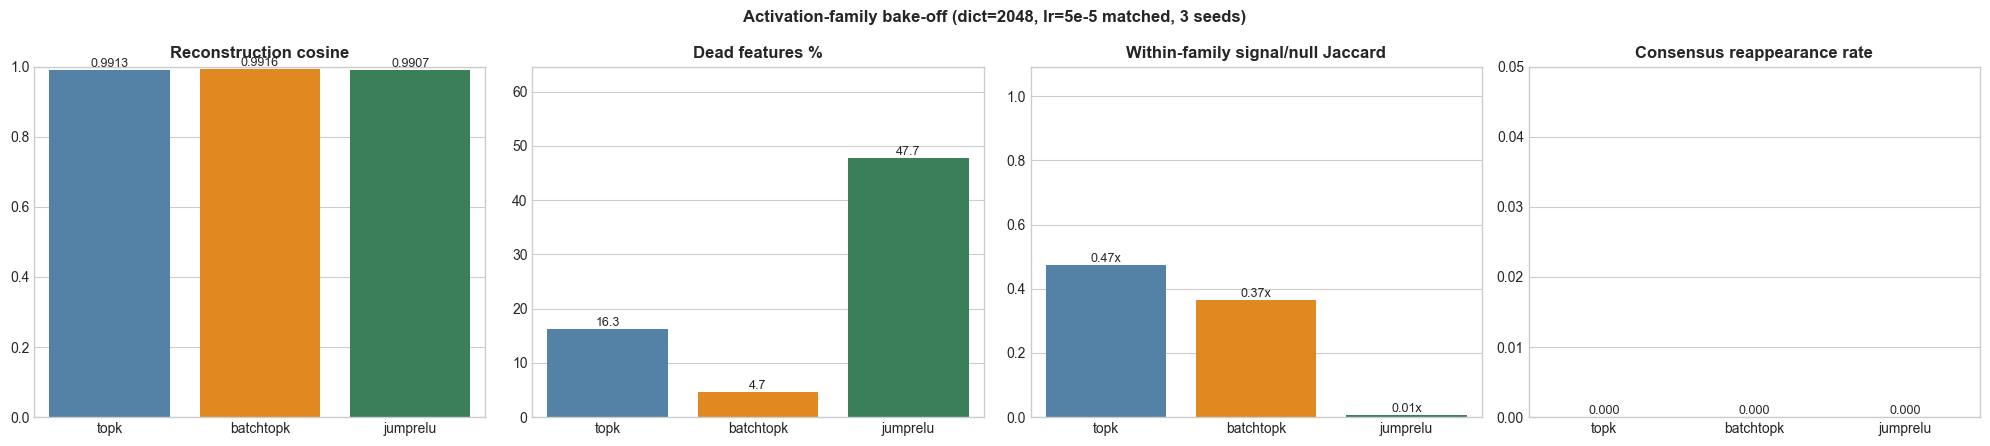

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation/a4_activation_comparison.png


In [14]:
import seaborn as sns

variants = ['topk', 'batchtopk', 'jumprelu']
recon_mean = [np.mean([per_variant_metrics[v][s]['recon_cos'] for s in ABLATION_SEEDS]) for v in variants]
dead_mean = [np.mean([per_variant_metrics[v][s]['dead_pct'] for s in ABLATION_SEEDS]) for v in variants]
s2n = [within_stability[v]['signal_to_null'] for v in variants]
cons_rate = [consensus[v]['consensus_rate'] for v in variants]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
pal = {'topk': 'steelblue', 'batchtopk': 'darkorange', 'jumprelu': 'seagreen'}

def bar(ax, vals, title, fmt='{:.3f}', ylim=None):
    sns.barplot(x=variants, y=vals, ax=ax,
                palette=[pal[v] for v in variants], hue=variants, legend=False)
    ax.set_title(title, fontweight='bold')
    for i, val in enumerate(vals):
        ax.text(i, val, fmt.format(val), ha='center', va='bottom', fontsize=9)
    if ylim:
        ax.set_ylim(ylim)

bar(axes[0], recon_mean, 'Reconstruction cosine', '{:.4f}', (0, 1))
bar(axes[1], dead_mean, 'Dead features %', '{:.1f}', (0, max(dead_mean) * 1.25 + 5))
bar(axes[2], s2n, 'Within-family signal/null Jaccard', '{:.2f}x', (0, max(s2n) * 1.25 + 0.5))
bar(axes[3], cons_rate, 'Consensus reappearance rate', '{:.3f}', (0, max(cons_rate) * 1.25 + 0.05))
fig.suptitle('Activation-family bake-off (dict=2048, lr=5e-5 matched, 3 seeds)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_activation_comparison.png"}')

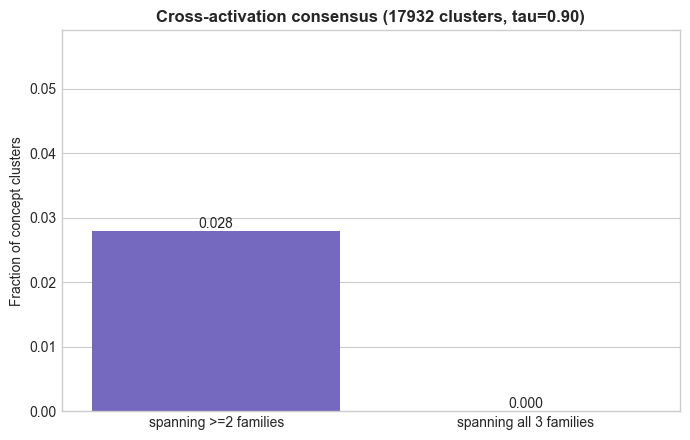

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/figures/ablation/a4_cross_activation_consensus.png


In [15]:
# Figure 3 — cross-activation consensus bar.
fig, ax = plt.subplots(figsize=(7, 4.5))
rates = [cross['spanning_2families_rate'], cross['spanning_3families_rate']]
labels = ['spanning >=2 families', 'spanning all 3 families']
sns.barplot(x=labels, y=rates, ax=ax, palette=['#6a5acd', '#2e8b57'], hue=labels, legend=False)
for i, r in enumerate(rates):
    ax.text(i, r, f'{r:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Fraction of concept clusters')
ax.set_title(f'Cross-activation consensus ({cross["n_clusters"]} clusters, tau=0.90)', fontweight='bold')
ax.set_ylim(0, max(rates) * 1.4 + 0.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'a4_cross_activation_consensus.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_DIR / "a4_cross_activation_consensus.png"}')

## 10. Persist results

Write `results/ablation/a4_activation.json` with all per-variant, cross-variant,
and cross-activation numbers.

In [16]:
def _clean(d):
    """Strip numpy arrays / tensors so the payload is JSON-serializable."""
    out = {}
    for k, v in d.items():
        if isinstance(v, np.ndarray):
            continue  # skip per-sample arrays
        if isinstance(v, torch.Tensor):
            out[k] = v.tolist()
        elif isinstance(v, np.generic):
            out[k] = v.item()
        else:
            out[k] = v
    return out

payload = {
    'ablation': '04_activation_bakeoff',
    'params': {
        'dict_size': DICT_SIZE,
        'activation_dim': ACTIVATION_DIM,
        'lr': LR,
        'steps': N_STEPS,
        'batch_size': BATCH_SIZE,
        'seeds': list(ABLATION_SEEDS),
        'primary_seed': PRIMARY_SEED,
        'k': K,
        'target_l0': TARGET_L0,
        'auxk_alpha': AUXK_ALPHA,
        'bandwidth': BANDWIDTH,
        'sparsity_penalty': SPARSITY_PENALTY,
        'sparsity_warmup_steps': SPARSITY_WARMUP_STEPS,
        'normalize_activations': False,
        'n_active_jaccard': N_ACTIVE,
        'n_test_samples': int(test_emb.shape[0]),
        'naming': 'gap-corrected (Soluzione 1: W_dec -= visual_centroid - text_centroid)',
    },
    'baseline_reference': {
        'recon_cos': 0.988, 'dead_pct': 44.0, 'mean_jaccard_index': 0.0038,
        'naming_mean': 0.3949, 'naming_max': 0.5457, 'dict_size': 4096,
        'naming_note': 'gap-corrected (Soluzione 1), seed 42',
    },
    'per_variant_metrics': {v: {int(s): _clean(per_variant_metrics[v][s]) for s in ABLATION_SEEDS}
                            for v in variants},
    'within_family_stability': {v: _clean(within_stability[v]) for v in variants},
    'consensus_reappearance': {v: _clean(consensus[v]) for v in variants},
    'cross_activation_consensus': _clean(cross),
    'naming_summary': {v: {k2: naming[v][k2] for k2 in ('n_live', 'mean_score', 'max_score')}
                       for v in variants},
}

results_path = RESULTS_DIR / 'a4_activation.json'
with open(results_path, 'w') as f:
    json.dump(payload, f, indent=2)
print(f'Saved: {results_path}  ({results_path.stat().st_size / 1024:.1f} KB)')

print('\n=== Headline summary ===')
print(f"{'variant':10s} {'recon':>7s} {'dead%':>6s} {'s/null':>7s} {'consensus':>9s} {'name_max':>8s}")
for v in variants:
    print(f"{v:10s} "
          f"{np.mean([per_variant_metrics[v][s]['recon_cos'] for s in ABLATION_SEEDS]):>7.4f} "
          f"{np.mean([per_variant_metrics[v][s]['dead_pct'] for s in ABLATION_SEEDS]):>6.1f} "
          f"{within_stability[v]['signal_to_null']:>7.2f} "
          f"{consensus[v]['consensus_rate']:>9.3f} "
          f"{naming[v]['max_score']:>8.4f}")
print(f"\nCross-activation: {cross['spanning_2families_rate']*100:.1f}% of {cross['n_clusters']} clusters "
      f"span >=2 families; {cross['spanning_3families_rate']*100:.1f}% span all 3.")

Saved: /Users/marcantoniolopez/Documents/github/xai-project-5/results/ablation/a4_activation.json  (6.1 KB)

=== Headline summary ===
variant      recon  dead%  s/null consensus name_max
topk        0.9913   16.3    0.47     0.000   0.5261
batchtopk   0.9916    4.7    0.37     0.000   0.5447
jumprelu    0.9907   47.7    0.01     0.000   0.5718

Cross-activation: 2.8% of 17932 clusters span >=2 families; 0.0% span all 3.


## 11. Notes & caveats

**Pre-registered hypothesis check.** If BatchTopK/JumpReLU do not beat TopK on
consensus-rate and dead%, the lr-matching trade-off (each variant's tuned default
sacrificed for a valid comparison) is a likely contributor.

**lr-matching trade-off.** TopK/BatchTopK auto-scale to ~2.8e-4 at dict_size=2048;
JumpReLU defaults to 7e-5. We pin all three at 5e-5 to kill the ~8x lr confound —
conservative, possibly under-training TopK/BatchTopK. Re-check at family-tuned lr
in a follow-up.

**Index-Jaccard is within-family only.** Cross-family index-Jaccard is meaningless
(different indices, different effective L0). We report renormalized within-family
Jaccard (n=20), signal-to-null ratio, consensus-reappearance, and cross-activation
consensus — all index/size-agnostic.

**Dead% definition.** Fraction of features never nonzero on the test set
(activation-based). Never read the trainers' `dead_features` counter (its
`10_000_000`-step threshold is meaningless at 12000 steps).